<a href="https://colab.research.google.com/github/Harshgadre/harsh/blob/main/01_Zomato.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df=pd.read_csv('/content/drive/MyDrive/11_Projects/Copy of zomato.csv')
df.sample(5)

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
51645,https://www.zomato.com/bangalore/raapchick-bro...,"Opposite Brookefield Mall, Kundanhalli, Brooke...",Raapchick,Yes,No,3.6 /5,49,080 41717785\n+91 9571153004,Brookefield,Quick Bites,Burgers,"Fast Food, Burger",300,"[('Rated 5.0', ""RATED\n I was randomly lookin...","['Chicken Wrap', 'Veg Crunch Burger', 'Spicy P...",Dine-out,Whitefield
10013,https://www.zomato.com/bangalore/multi-cakes-1...,"86, 3rd Main, Dollars Colony, 4th Phase, JP Na...",Multi Cakes,No,No,3.7/5,44,080 26590344\r\n+91 9986588882,JP Nagar,Dessert Parlor,"Irish Coffee, Eggless Cake","Bakery, Desserts",200,"[('Rated 1.0', ""RATED\n Today, I was running ...",[],Delivery,BTM
22659,https://www.zomato.com/bangalore/miss-momo-btm...,"16/19, Ground Floor, Platinum Arch, 1st Cross ...",Miss Momo,Yes,No,3.2/5,10,+91 9019689798,BTM,Quick Bites,NaN,"Tibetan, Momos",250,"[('Rated 1.0', 'RATED\n please do not order f...",[],Delivery,JP Nagar
25281,https://www.zomato.com/bangalore/pizza-hut-kal...,"310, AVR Base, 5th B Cross, HRBR Layout, 3rd B...",Pizza Hut,Yes,No,2.7/5,434,080 39883988\r\n080 25435999,Kalyan Nagar,Casual Dining,"Kurkure Pizza, Garlic Bread, Pasta, Masala Lem...","Pizza, Fast Food",750,"[('Rated 2.0', 'RATED\n The last time I order...","['Garlic Bread Spicy Supreme', 'Spicy Chicken'...",Delivery,Kammanahalli
1657,https://www.zomato.com/bangalore/delicious-nig...,"18, 1st Cross, Jambusavari Dinne, JP Nagar, Ba...",Delicious Night,No,No,NaN,0,080 65777883,JP Nagar,Delivery,NaN,"Biryani, Chinese, Fast Food",200,"[('Rated 5.0', 'RATED\n Awesome food and fast...",[],Delivery,Bannerghatta Road


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object
 8   location                     51696 non-null  object
 9   rest_type                    51490 non-null  object
 10  dish_liked                   23639 non-null  object
 11  cuisines                     51672 non-null  object
 12  approx_cost(for two people)  51371 non-null  object
 13  reviews_list                 51

In [ ]:
# df['menu_item'].value_counts()

In [ ]:
df=df.drop(['address','phone','dish_liked','listed_in(city)','cuisines','reviews_list','menu_item'],axis=1)
df.head()

,url,name,online_order,book_table,rate,votes,location,rest_type,approx_cost(for two people),listed_in(type)
0,https://www.zomato.com/bangalore/jalsa-banasha...,Jalsa,Yes,Yes,4.1/5,775,Banashankari,Casual Dining,800,Buffet
1,https://www.zomato.com/bangalore/spice-elephan...,Spice Elephant,Yes,No,4.1/5,787,Banashankari,Casual Dining,800,Buffet
2,https://www.zomato.com/SanchurroBangalore?cont...,San Churro Cafe,Yes,No,3.8/5,918,Banashankari,"Cafe, Casual Dining",800,Buffet
3,https://www.zomato.com/bangalore/addhuri-udupi...,Addhuri Udupi Bhojana,No,No,3.7/5,88,Banashankari,Quick Bites,300,Buffet
4,https://www.zomato.com/bangalore/grand-village...,Grand Village,No,No,3.8/5,166,Basavanagudi,Casual Dining,600,Buffet


In [ ]:
df['rate'].unique()

array(['4.1/5', '3.8/5', '3.7/5', '3.6/5', '4.6/5', '4.0/5', '4.2/5',
       '3.9/5', '3.1/5', '3.0/5', '3.2/5', '3.3/5', '2.8/5', '4.4/5',
       '4.3/5', 'NEW', '2.9/5', '3.5/5', nan, '2.6/5', '3.8 /5', '3.4/5',
       '4.5/5', '2.5/5', '2.7/5', '4.7/5', '2.4/5', '2.2/5', '2.3/5',
       '3.4 /5', '-', '3.6 /5', '4.8/5', '3.9 /5', '4.2 /5', '4.0 /5',
       '4.1 /5', '3.7 /5', '3.1 /5', '2.9 /5', '3.3 /5', '2.8 /5',
       '3.5 /5', '2.7 /5', '2.5 /5', '3.2 /5', '2.6 /5', '4.5 /5',
       '4.3 /5', '4.4 /5', '4.9/5', '2.1/5', '2.0/5', '1.8/5', '4.6 /5',
       '4.9 /5', '3.0 /5', '4.8 /5', '2.3 /5', '4.7 /5', '2.4 /5',
       '2.1 /5', '2.2 /5', '2.0 /5', '1.8 /5'], dtype=object)

In [ ]:
def cleaning_rate(value):
  if(value=='NEW' or value=='-'):
    return np.nan
  else:
    return float(str(value).split('/')[0])

In [ ]:
cleaning_rate('3.8/5')

3.8

In [ ]:
df['rate']= df['rate'].apply(cleaning_rate)
df['rate'].unique()

array([4.1, 3.8, 3.7, 3.6, 4.6, 4. , 4.2, 3.9, 3.1, 3. , 3.2, 3.3, 2.8,
       4.4, 4.3, nan, 2.9, 3.5, 2.6, 3.4, 4.5, 2.5, 2.7, 4.7, 2.4, 2.2,
       2.3, 4.8, 4.9, 2.1, 2. , 1.8])

In [ ]:
df.isna().sum()

,0
url,0
name,0
online_order,0
book_table,0
rate,10052
votes,0
location,21
rest_type,227
approx_cost(for two people),346
listed_in(type),0


In [ ]:
df.isna().sum()

,0
url,0
name,0
online_order,0
book_table,0
rate,10052
votes,0
location,21
rest_type,227
approx_cost(for two people),346
listed_in(type),0


In [ ]:
df['rate']=df['rate'].fillna(np.round(df['rate'].mean(),1))

In [ ]:
df.isna().sum()

,0
url,0
name,0
online_order,0
book_table,0
rate,0
votes,0
location,21
rest_type,227
approx_cost(for two people),346
listed_in(type),0


In [ ]:
df=df.dropna()

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 51167 entries, 0 to 51716
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   url                          51167 non-null  object 
 1   name                         51167 non-null  object 
 2   online_order                 51167 non-null  object 
 3   book_table                   51167 non-null  object 
 4   rate                         51167 non-null  float64
 5   votes                        51167 non-null  int64  
 6   location                     51167 non-null  object 
 7   rest_type                    51167 non-null  object 
 8   approx_cost(for two people)  51167 non-null  object 
 9   listed_in(type)              51167 non-null  object 
dtypes: float64(1), int64(1), object(8)
memory usage: 4.3+ MB


In [ ]:
df['approx_cost(for two people)'].unique()

array(['800', '300', '600', '700', '550', '500', '450', '650', '400',
       '900', '200', '750', '150', '850', '100', '1,200', '350', '250',
       '950', '1,000', '1,500', '1,300', '199', '80', '1,100', '160',
       '1,600', '230', '130', '50', '190', '1,700', '1,400', '180',
       '1,350', '2,200', '2,000', '1,800', '1,900', '330', '2,500',
       '2,100', '3,000', '2,800', '3,400', '40', '1,250', '3,500',
       '4,000', '2,400', '2,600', '120', '1,450', '469', '70', '3,200',
       '60', '560', '240', '360', '6,000', '1,050', '2,300', '4,100',
       '5,000', '3,700', '1,650', '2,700', '4,500', '140'], dtype=object)

In [ ]:
def cleaned_cost(value):
  if ',' in value:
    value=value.replace(',','')
    return float(value)
  else:
    return float(value)

In [ ]:
df['approx_cost(for two people)']=df['approx_cost(for two people)'].apply(cleaned_cost)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 51167 entries, 0 to 51716
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   url                          51167 non-null  object 
 1   name                         51167 non-null  object 
 2   online_order                 51167 non-null  object 
 3   book_table                   51167 non-null  object 
 4   rate                         51167 non-null  float64
 5   votes                        51167 non-null  int64  
 6   location                     51167 non-null  object 
 7   rest_type                    51167 non-null  object 
 8   approx_cost(for two people)  51167 non-null  float64
 9   listed_in(type)              51167 non-null  object 
dtypes: float64(2), int64(1), object(7)
memory usage: 4.3+ MB


In [ ]:
df['approx_cost(for two people)'].unique()

array([ 800.,  300.,  600.,  700.,  550.,  500.,  450.,  650.,  400.,
        900.,  200.,  750.,  150.,  850.,  100., 1200.,  350.,  250.,
        950., 1000., 1500., 1300.,  199.,   80., 1100.,  160., 1600.,
        230.,  130.,   50.,  190., 1700., 1400.,  180., 1350., 2200.,
       2000., 1800., 1900.,  330., 2500., 2100., 3000., 2800., 3400.,
         40., 1250., 3500., 4000., 2400., 2600.,  120., 1450.,  469.,
         70., 3200.,   60.,  560.,  240.,  360., 6000., 1050., 2300.,
       4100., 5000., 3700., 1650., 2700., 4500.,  140.])

In [ ]:
restaurant_type=df['rest_type'].value_counts()
restaurant_type

,count
rest_type,
Quick Bites,19048
Casual Dining,10275
Cafe,3687
Delivery,2587
Dessert Parlor,2245
...,...
"Dessert Parlor, Kiosk",2
"Dessert Parlor, Food Court",2
"Food Court, Beverage Shop",2


In [ ]:
type_below_500=restaurant_type[restaurant_type < 500]

In [ ]:
def cleaned_type(value):
  if(value in type_below_500):
    return 'Others'
  else:
    return value

In [ ]:
df['rest_type']=df['rest_type'].apply(cleaned_type)
df['rest_type'].value_counts()                              #.plot(kind='bar')

,count
rest_type,
Quick Bites,19048
Casual Dining,10275
Others,6860
Cafe,3687
Delivery,2587
Dessert Parlor,2245
"Takeaway, Delivery",2016
Bakery,1141
"Casual Dining, Bar",1136


In [ ]:
res_loc=df['location'].value_counts()
loc_below_500=res_loc[res_loc <500]

In [ ]:
def cleaning_location(loc):
  if loc in loc_below_500:
    return 'Others'
  elif ('Koramangala' in loc):
    return'Koramangala'
  else:
    return loc

In [ ]:
df['location']= df['location'].apply(cleaning_location)
df['location'].value_counts()

,count
location,
Others,8021
Koramangala,7040
BTM,5071
HSR,2496
JP Nagar,2219
Whitefield,2117
Indiranagar,2033
Jayanagar,1916
Marathahalli,1811


# Restaurants delivering Online or not

Text(0.5, 1.0, 'Restourants delivering Online or not')

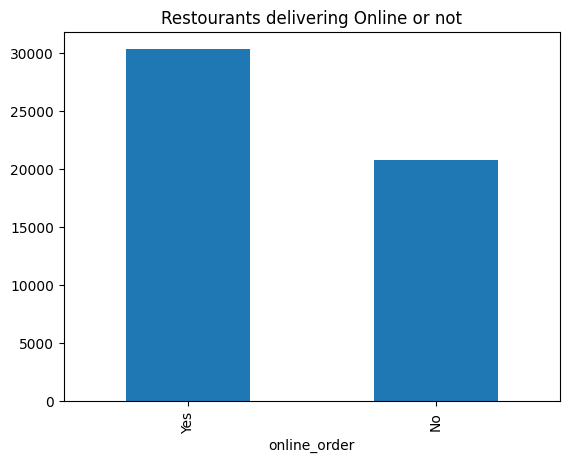

In [ ]:
df['online_order'].value_counts().plot(kind='bar')
plt.title('Restourants delivering Online or not')

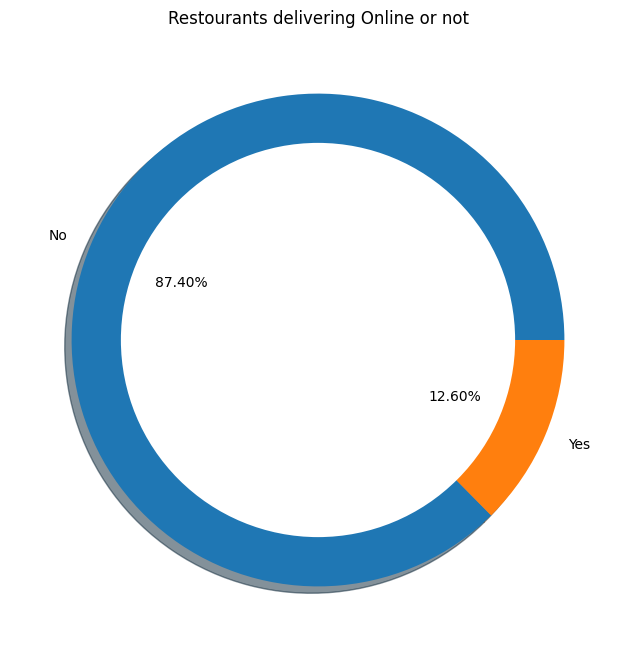

In [ ]:
plt.figure(figsize=(8,8))
plt.pie(df['book_table'].value_counts().values,labels=df['book_table'].value_counts().index,
        autopct='%1.2f%%',shadow=True)
centre_circle=plt.Circle((0,0),0.8, fc='white')
fig=plt.gcf()
fig.gca().add_artist(centre_circle) #Gets current figure
plt.title('Restourants delivering Online or not') #Adds white circle to the center
plt.show()

In [ ]:
df['book_table'].value_counts()

,count
book_table,
No,44718
Yes,6449


<Axes: title={'center': 'Most popular '}, ylabel='rest_type'>

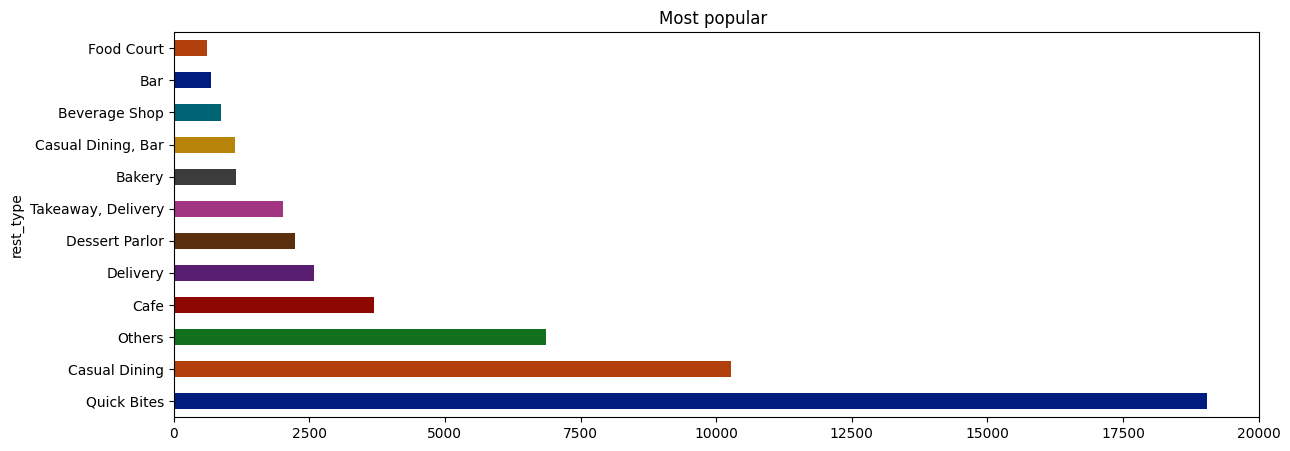

In [ ]:
plt.figure(figsize=(14,5))
plt.title('Most popular ')
df['rest_type'].value_counts().plot(kind='barh',color=sns.color_palette('dark'))

In [ ]:
res_cost=df['approx_cost(for two people)'].groupby(df['name'],sort=True)


Text(0.5, 1.0, 'Avg cost for 2 people - Top 10 restaurants')

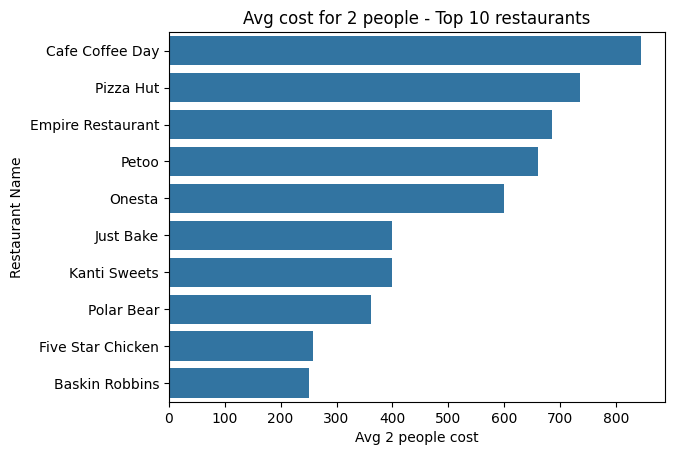

In [ ]:
res_cost=df['approx_cost(for two people)'].groupby(df['name'],sort=True)

dict1={}

for i,j in df['name'].value_counts()[:10].to_dict().items():
  dict1[i]= np.round(res_cost.get_group(i).mean(),2)

cost_df = pd.DataFrame(list(dict1.items()),columns=['Restaurant Name','Avg 2 people cost'])

sns.barplot(data=cost_df.sort_values(by=['Avg 2 people cost'],ascending=False),
            x='Avg 2 people cost',y='Restaurant Name')

plt.title('Avg cost for 2 people - Top 10 restaurants')

In [ ]:
cost_df

,Restaurant Name,Avg 2 people cost
0,Cafe Coffee Day,844.79
1,Onesta,600.00
2,Just Bake,400.00
3,Empire Restaurant,685.21
4,Five Star Chicken,257.86
5,Kanti Sweets,400.00
6,Petoo,659.85
7,Polar Bear,361.54
8,Baskin Robbins,251.56
9,Pizza Hut,736.29
